In [147]:
import pandas as pd
import numpy as np

In [148]:
df = pd.read_csv(r"C:\Users\Junayed\nyc-311-resolution-time-analysis\data\clean\311_jan_week1_clean.csv")

In [149]:
df.shape

(85122, 11)

### Analyze Full Frequency Distribution of Resolution Turnaround

Evaluate the value count distribution of `Resolution_Days` across all 389 unique duration lengths:

* **High Front-End Concentration:** Over $65\%$ of cases (**55,687**) are resolved on the same day (`0` days), and over $79\%$ are completed within 24–48 hours (`0`–`1` days: **67,888** tickets).
* **Rapid Drop-Off:** Resolution counts decay sharply from Day 0 down through Day 4 (**917** tickets), illustrating standard operational throughput for high-volume routine complaints.
* **Extreme Tail Dispersion:** The existence of 389 distinct day counts with single-ticket outliers stretching up to several hundred days (e.g., 222, 285, 336, 503, 582) visually confirms a heavily right-skewed distribution driven by delayed administrative closures or complex field investigations.

In [150]:
df["Resolution_Days"].value_counts()

Resolution_Days
0      55687
1      12201
2       5024
3       2261
4        917
       ...  
222        1
582        1
336        1
285        1
503        1
Name: count, Length: 389, dtype: int64

### Inspect Top 10 Most Frequent Resolution Durations

Examine the highest-frequency turnaround times to understand operational velocity across typical service requests:

* **Dominant Velocity:** Turnaround times of $0$ to $2$ days comprise the vast majority of the top tiers, led heavily by same-day closures (**55,687** tickets) and 1-day completions (**12,201** tickets).
* **Decay Trajectory:** Volume decreases monotonically from Day 0 through Day 7, reflecting standard resolution curves where simpler operational tasks are cleared early in the ticket lifecycle.
* **Slight Non-Linearity (Days 8–9):** Day 9 (**369** tickets) marginally outpaces Day 8 (**317** tickets), likely reflecting post-weekend administrative batch closures or scheduled review cycles.

In [151]:
df["Resolution_Days"].value_counts().head(10)

Resolution_Days
0    55687
1    12201
2     5024
3     2261
4      917
5      594
6      567
7      509
9      369
8      317
Name: count, dtype: int64

In [152]:
df["Resolution_Days"].value_counts().sort_index(ascending=False).head(10)

Resolution_Days
622    1
621    2
620    1
619    1
600    1
592    1
591    1
582    1
581    1
576    1
Name: count, dtype: int64

### Analyze Complaint Type Frequency Distribution

Evaluate the overall volume and diversity of service request categories across all 133 unique complaint classifications:

* **Primary Drivers:** The top three categories alone account for the vast majority of intake:
  * **Noise - Residential:** Dominates the dataset with **30,224** records ($>35\%$ of total complaints).
  * **Heat/Hot Water:** Represents the second largest share with **14,711** records, typical for seasonal winter demand in early January.
  * **Illegal Parking:** Logs **9,745** records, making quality-of-life and curb-space enforcement top municipal priorities.
* **Secondary Volume:** Issues like `Blocked Driveway` (**3,297**) and `Street Condition` (**1,310**) represent moderate recurring city service needs.
* **Long Tail Distribution:** The remaining categories taper off sharply into single-incident specialized complaints (e.g., `Scaffold Safety`, `Pet Shop`, `Building Condition`), illustrating broad operational scope across NYC agencies.

In [153]:
df["Complaint_Type"].value_counts()

Complaint_Type
Noise - Residential               30224
Heat/Hot Water                    14711
Illegal Parking                    9745
Blocked Driveway                   3297
Street Condition                   1310
                                  ...  
Posting Advertisement                 1
Pet Shop                              1
Building Condition                    1
Scaffold Safety                       1
Institution Disposal Complaint        1
Name: count, Length: 133, dtype: int64

### Inspect Top 10 Most Frequent Complaint Types

Examine the ten highest-volume service request categories to identify the primary municipal drivers across New York City:

* **Dominant Concerns:** Quality-of-life and residential comfort issues dominate citywide intake:
  * **Residential Living:** `Noise - Residential` (**30,224**) and `Heat/Hot Water` (**14,711**) alone account for over $52\%$ of all closed requests.
  * **Curb Management & Traffic:** `Illegal Parking` (**9,745**), `Blocked Driveway` (**3,297**), and `Abandoned Vehicle` (**1,195**) represent major street enforcement workloads.
* **Environmental & Infrastructure:** `Street Condition` (**1,310**), `Unsanitary Condition` (**1,273**), and `Water System` (**954**) reflect essential neighborhood infrastructure and sanitation maintenance.
* **Secondary Noise Channels:** Public and commercial noise complaints (`Noise - Commercial`: **1,058**; `Noise - Street/Sidewalk`: **1,054**) add further burden to municipal sound monitoring beyond residential properties.

In [154]:
df["Complaint_Type"].value_counts().head(10)

Complaint_Type
Noise - Residential        30224
Heat/Hot Water             14711
Illegal Parking             9745
Blocked Driveway            3297
Street Condition            1310
Unsanitary Condition        1273
Abandoned Vehicle           1195
Noise - Commercial          1058
Noise - Street/Sidewalk     1054
Water System                 954
Name: count, dtype: int64

### Final Geographic Distribution by Borough (Post-Cleaning)

Evaluate the final distribution of closed service requests across all five NYC boroughs following outlier removal, missing-value filtering, and deduplication:

* **Cohort Integrity:** The post-cleaning volume confirms **85,122** verified complaints fully attributed across the five boroughs with zero unspecified entries.
* **Volume Distribution:**
  * **Bronx:** Remains the primary source of service requests at **37,641** cases ($44.2\%$ of total volume).
  * **Brooklyn:** Represents the second-highest concentration with **18,859** complaints ($22.2\%$).
  * **Queens & Manhattan:** Account for **14,306** ($16.8\%$) and **12,243** ($14.4\%$) records, respectively.
  * **Staten Island:** Accounts for the smallest operational volume at **2,073** requests ($2.4\%$).
* **Consistency Check:** Proportional representation across boroughs remains stable compared to the initial raw intake, confirming that data hygiene filters did not introduce regional sampling bias.

In [155]:
df["Borough"].value_counts()

Borough
Bronx            37641
Brooklyn         18859
Queens           14306
Manhattan        12243
Staten Island     2073
Name: count, dtype: int64

### Analyze Service Request Volume by Responding Agency

Evaluate operational workload distribution across municipal departments handling closed 311 tickets:

* **Primary Responders:** Two agencies absorb over $80\%$ of total service request intake:
  * **NYPD (Police Department):** Leads citywide volume with **49,047** tickets ($57.6\%$), handling quality-of-life enforcement including residential/commercial noise, blocked driveways, and illegal parking.
  * **HPD (Housing Preservation & Development):** Manages **19,787** requests ($23.2\%$), predominantly addressing residential heating, hot water, and unsanitary building conditions.
* **Secondary Responders:**
  * **DSNY (Sanitation):** **4,674** tickets covering illegal dumping and collection concerns.
  * **DOT (Transportation):** **3,472** tickets addressing street, sidewalk, and traffic condition repairs.
  * **DEP (Environmental Protection):** **2,766** complaints for water system, sewer, and environmental noise issues.
* **Specialized Long Tail:** Specialized departments—including **DOB** (Buildings: 1,558), **DOHMH** (Health: 1,237), **DPR** (Parks: 898), **TLC** (Taxi & Limousine: 526), **EDC**, **DHS**, **DCWP**, **DOE**, and **OTI** (6 tickets)—manage low-volume, jurisdiction-specific cases.

In [156]:
df["Agency"].value_counts()

Agency
NYPD     49047
HPD      19787
DSNY      4674
DOT       3472
DEP       2766
DOB       1558
DOHMH     1237
DPR        898
TLC        526
EDC        452
DHS        355
DCWP       291
DOE         53
OTI          6
Name: count, dtype: int64

### Identify the Top 20 Slowest Service Request Categories

Rank complaint types by median turnaround duration (`.sort_values(ascending=False)`) to pinpoint operational bottlenecks and long-cycle municipal services:

* **Forestry & Tree Work (DPR):** Severe delays characterize arboricultural services—`Uprooted Stump` leads citywide resolution times at a median of **175.5 days**, followed by `New Tree Request` at **147.0 days** and `Root/Sewer/Sidewalk Condition` at **49.0 days**, reflecting seasonal planting schedules and specialized contractor dispatch.
* **Complex Environmental & Administrative Reviews:** 
  * `Noise - Helicopter` requires **138.0 days**, as aviation noise involves cross-jurisdictional reviews with the FAA and EDC.
  * Specialized building audits under `Special Projects Inspection Team (Spit)` require **101.0 days**.
* **Regulatory Compliance & Licensing (TLC & DOHMH):** Consumer regulatory matters take several months—`Green Taxi Complaint` (**96.5 days**), `For Hire Vehicle Complaint` (**79.0 days**), `Taxi Complaint` (**76.5 days**), and `Food Establishment` inspections (**60.0 days**) involve evidence audits, driver hearings, and scheduled physical site visits.
* **Property & Facility Conditions:** Cases like `Lot Condition` (**93.0 days**) and `Building/Use` (**63.0 days**) reflect legal notice periods, property owner remediation windows, and repeat inspection requirements.

In [157]:
df.groupby("Complaint_Type")["Resolution_Days"].median().sort_values(ascending=False).head(20)

Complaint_Type
Uprooted Stump                             175.5
New Tree Request                           147.0
Noise - Helicopter                         138.0
Special Projects Inspection Team (Spit)    101.0
Green Taxi Complaint                        96.5
Lot Condition                               93.0
For Hire Vehicle Complaint                  79.0
Taxi Complaint                              76.5
Bench                                       69.5
Building/Use                                63.0
Food Establishment                          60.0
Non-Residential Heat                        60.0
Smoking Or Vaping                           60.0
School Maintenance                          50.0
Root/Sewer/Sidewalk Condition               49.0
Graffiti                                    34.0
General                                     24.0
Appliance                                   22.0
Outside Building                            21.5
Unsanitary Condition                        20.0
Name:

### Identify the Fastest Service Request Categories (Same-Day Closures)

Inspect complaint categories sorted ascendingly by median resolution time to understand which issues receive immediate operational closure:

* **Instant Dispatch & Urgent Response (Median = 0.0 Days):** A substantial cluster of service request categories consistently close on the same calendar day they are created.
* **Public Safety & Police Intervention (NYPD):** Quality-of-life and acute public enforcement categories—including `Blocked Driveway`, `Abandoned Vehicle`, `Drinking`, `Drug Activity`, `Disorderly Youth`, and `Illegal Fireworks`—are dispatched directly to local precincts and resolved within hours.
* **Hazardous Environmental Health (DEP / DOHMH):** Immediate-response public health risks such as `Hazardous Materials` and `Asbestos` exhibit same-day median turnaround due to mandated emergency response protocols.
* **Operational Implication:** The heavy concentration of zero-day medians demonstrates why the citywide median resolution time remains $0.0$ days despite multi-month outliers in forestry and licensing.

In [158]:
df.groupby("Complaint_Type")["Resolution_Days"].median().sort_values(ascending=True).head(20)

Complaint_Type
Abandoned Vehicle                0.0
Animal In A Park                 0.0
Asbestos                         0.0
Animal-Abuse                     0.0
Blocked Driveway                 0.0
Building Condition               0.0
Bike/Roller/Skate Chronic        0.0
Best/Site Safety                 0.0
Derelict Vehicles                0.0
Drinking                         0.0
Disorderly Youth                 0.0
Dirty Condition                  0.0
Commercial Disposal Complaint    0.0
Bus Stop Shelter Placement       0.0
Encampment                       0.0
Drug Activity                    0.0
Hazardous Materials              0.0
Illegal Fireworks                0.0
Illegal Animal Sold              0.0
Illegal Animal Kept As Pet       0.0
Name: Resolution_Days, dtype: float64

### Quantify Unique Complaint Categories

Compute the number of distinct complaint types present in the cleaned dataset using `.nunique()`:

* **Category Count:** Exactly **133 unique complaint types** are represented across the 85,122 validated service requests.

In [159]:
complaints_type = df["Complaint_Type"].nunique()
print(complaints_type)

133


### Tabulate Complaint Category Volumes (`complaint_dist`)

Convert the frequency series of `Complaint_Type` into a structured summary table using `.value_counts().reset_index()`:

* **Structure:** Produces a 133-row reference table linking each complaint type directly to its absolute ticket volume (`Ticket_Count`), sorted in descending order of frequency.
* **Volume Distribution Highlights:**
  * **Head of Distribution:** Dominated by quality-of-life and residential comfort issues, led by `Noise - Residential` (**30,224**) and `Heat/Hot Water` (**14,711**).
  * **Tail of Distribution:** Displays multiple low-incidence categories logging exactly **1** occurrence (e.g., `Posting Advertisement`, `Pet Shop`, `Building Condition`, `Scaffold Safety`), demonstrating the long-tail operational profile of 311 intake.
* **Purpose:** Serves as the base DataFrame for calculating individual and cumulative percentage shares to evaluate categorical concentration.

In [160]:
complaint_dist = (
    df["Complaint_Type"].value_counts().reset_index(name="Ticket_Count")
)
complaint_dist

,Complaint_Type,Ticket_Count
0,Noise - Residential,30224
1,Heat/Hot Water,14711
2,Illegal Parking,9745
3,Blocked Driveway,3297
4,Street Condition,1310
...,...,...
128,Posting Advertisement,1
129,Pet Shop,1
130,Building Condition,1
131,Scaffold Safety,1


### Quantify Relative Volume Share Across Top 20 Complaint Types

Calculate the individual percentage share of total intake ($N = 85,122$) for each complaint category to assess workload distribution:

* **Tier 1 — Core Operational Drivers ($> 10\%$ each):**
  * `Noise - Residential`: **35.51%**
  * `Heat/Hot Water`: **17.28%**
  * `Illegal Parking`: **11.45%**
  * *Insight:* The top three categories alone account for **64.24%** of all resolved service requests, demonstrating that municipal intake is overwhelmingly dominated by quality-of-life and basic residential heating concerns.
* **Tier 2 — Moderate Recurring Volume ($1\% - 4\%$ each):**
  * Categories such as `Blocked Driveway` (**3.87%**), `Street Condition` (**1.54%**), `Unsanitary Condition` (**1.50%**), and `Abandoned Vehicle` (**1.40%**) capture consistent enforcement and infrastructure demands.
  * Commercial and street-level noise combine for an additional **2.48%** of ticket volume.
* **Tier 3 — Sub-1% Niche Categories:**
  * By Rank 14 (`Traffic Signal Condition` at **0.99%**), individual category contributions fall below $1.0\%$, highlighting a steep decay where the majority of NYC's 133 complaint types represent minor fractional shares of total city operations.

In [161]:
complaint_dist["Percentage"] = (complaint_dist["Ticket_Count"] / len(df) * 100).round(2)

In [162]:
complaint_dist[["Complaint_Type", "Percentage"]].head(20)

,Complaint_Type,Percentage
0,Noise - Residential,35.51
1,Heat/Hot Water,17.28
2,Illegal Parking,11.45
3,Blocked Driveway,3.87
4,Street Condition,1.54
5,Unsanitary Condition,1.50
6,Abandoned Vehicle,1.40
7,Noise - Commercial,1.24
8,Noise - Street/Sidewalk,1.24
9,Water System,1.12


### Evaluate Cumulative Volume Share Across Top 10 Complaint Types

Compute running cumulative percentages using `.cumsum()` to measure category concentration and assess the Pareto distribution of service requests:

* **Extreme Initial Concentration:**
  * **Top 2 Categories (52.79%):** `Noise - Residential` and `Heat/Hot Water` together comprise over half of all service request volume in the city.
  * **Top 3 Categories (64.24%):** Incorporating `Illegal Parking` brings the combined share to nearly two-thirds of all resolved complaints.
* **Top 10 Benchmark (76.15%):** Just 10 complaint types account for over three-quarters of the entire dataset ($64,821$ out of $85,122$ tickets).
* **Pareto Dynamics:** While 133 distinct complaint categories exist, operational intake exhibits extreme non-uniformity—less than $8\%$ of category types generate more than $76\%$ of all municipal workload, leaving the remaining 123 categories to share less than $24\%$.

In [163]:
complaint_dist["Cumulative_Percentage"] = complaint_dist["Percentage"].cumsum().round(2)

complaint_dist.head(10)

,Complaint_Type,Ticket_Count,Percentage,Cumulative_Percentage
0,Noise - Residential,30224,35.51,35.51
1,Heat/Hot Water,14711,17.28,52.79
2,Illegal Parking,9745,11.45,64.24
3,Blocked Driveway,3297,3.87,68.11
4,Street Condition,1310,1.54,69.65
5,Unsanitary Condition,1273,1.50,71.15
6,Abandoned Vehicle,1195,1.40,72.55
7,Noise - Commercial,1058,1.24,73.79
8,Noise - Street/Sidewalk,1054,1.24,75.03
9,Water System,954,1.12,76.15


**Does volume matter?**

In [164]:
df.loc[df["Complaint_Type"] == "Uprooted Stump"]

,Unique_Key,Created_Date,Closed_Date,Agency,Complaint_Type,Descriptor,Borough,Incident_Zip,Status,Open_Data_Channel_Type,Resolution_Days
30697,63618380,2025-01-03 12:46:19,2025-02-27 10:36:51,DPR,Uprooted Stump,Remove Stump,Queens,11373.0,Closed,Phone,54
65805,63656468,2025-01-06 13:19:26,2025-10-31 08:53:01,DPR,Uprooted Stump,Remove Stump,Queens,11419.0,Closed,Phone,297


### Comparative Evaluation: Volume vs. Turnaround Across Fastest Categories

Inspect complaint volume (`count`) across service categories achieving same-day median resolution (`median == 0.0`):

* **High-Volume Velocity:** Rapid same-day resolution is maintained even under heavy operational load:
  * `Blocked Driveway`: **3,297 tickets** resolved with a median of **0.0 days**.
  * `Abandoned Vehicle`: **1,195 tickets** resolved with a median of **0.0 days**.
  * `Dirty Condition`: **932 tickets** resolved with a median of **0.0 days**.
* **Low-Volume Urgency:** Acute complaints with minimal occurrences such as `Disorderly Youth` ($N = 1$), `Hazardous Materials` ($N = 21$), and `Asbestos` ($N = 17$) also resolve within 0 days due to immediate public safety routing.
* **Dual-Perspective Finding (Slowest vs. Fastest):**
  * The slowest complaints ($>60$ days) almost universally have tiny volumes ($N < 30$), ruling out system overload as the cause of delays.
  * The fastest complaints ($0.0$ days) encompass both single-ticket hazards and massive multi-thousand-ticket operations.
  * **Core Takeaway:** Resolution turnaround is driven by operational workflows (immediate field dispatch vs. contractor scheduling and administrative hearings), not incoming ticket volume.

In [165]:
does_volume_matter = (
    
    df.groupby("Complaint_Type")["Resolution_Days"]
    .agg(["median", "count"])
    .sort_values(by="median", ascending=False)

)

does_volume_matter.head(20)

,median,count
Complaint_Type,,
Uprooted Stump,175.5,2
New Tree Request,147.0,30
Noise - Helicopter,138.0,452
Special Projects Inspection Team (Spit),101.0,77
Green Taxi Complaint,96.5,4
Lot Condition,93.0,3
For Hire Vehicle Complaint,79.0,278
Taxi Complaint,76.5,124
Bench,69.5,2


In [166]:
is_volume_matter = (
    
    df.groupby("Complaint_Type")["Resolution_Days"]
    .agg(["median", "count"])
    .sort_values(by="median", ascending=True)

)

is_volume_matter.head(20)

,median,count
Complaint_Type,,
Abandoned Vehicle,0.0,1195
Animal In A Park,0.0,65
Asbestos,0.0,17
Animal-Abuse,0.0,207
Blocked Driveway,0.0,3297
Building Condition,0.0,1
Bike/Roller/Skate Chronic,0.0,6
Best/Site Safety,0.0,5
Derelict Vehicles,0.0,731


### Analyze Median Resolution Duration by Borough

Examine median turnaround times across all five boroughs to evaluate geographic disparity in service delivery:

* **Uniform Median Across All Boroughs ($0.0$ Days):** Every single borough exhibits a median resolution turnaround of exactly **0.0 days**, indicating that over half of all service requests within each borough are resolved within the same calendar day.
* **Consistency Across Volume Scales:** This uniform velocity holds true regardless of complaint intake scale from high-density boroughs like the **Bronx** ($37,641$ tickets) and **Brooklyn** ($18,859$ tickets) down to **Staten Island** ($2,073$ tickets).
* **Underlying Driver:** The citywide dominance of rapid-response NYPD and HPD categories (`Noise - Residential`, `Illegal Parking`, `Heat/Hot Water`) anchors the 50th percentile at zero days across all geographic administrative zones.
* **Next Analytical Step:** Because medians mask variations within the long tail, evaluating higher percentiles (e.g., 75th or 90th) or arithmetic means per borough will provide a clearer picture of regional backlog differences.

In [167]:
df.groupby('Borough')["Resolution_Days"].median().sort_values(ascending=False)

Borough
Bronx            0.0
Brooklyn         0.0
Manhattan        0.0
Queens           0.0
Staten Island    0.0
Name: Resolution_Days, dtype: float64

In [168]:
df.groupby('Borough')["Resolution_Days"].mean().sort_values(ascending=False)

Borough
Manhattan        13.685943
Queens            9.891724
Staten Island     8.683550
Brooklyn          7.351768
Bronx             2.655030
Name: Resolution_Days, dtype: float64

### Borough Resolution Disparity Ranked by Mean Turnaround (`percentile_check`)

Sort borough-level turnaround metrics in ascending order of arithmetic mean (`.sort_values(by="Mean", ascending=True)`) to rank boroughs from fastest to slowest overall resolution:

* **Top Performer : The Bronx:**
  * Displays the lowest average turnaround (**Mean: 2.66 days**) despite logging the largest workload (**37,641 tickets**, $44.2\%$ of city total).
  * **90% of all Bronx requests resolve within 1.0 day** ($\text{P90} = 1.0$), demonstrating rapid dispatch protocols for emergency heat and residential noise enforcement.
* **Mid-Tier Cluster : Brooklyn, Staten Island & Queens:**
  * **Brooklyn:** Mean of **7.35 days**, with 75% resolved in $\le 2$ days and 90% within 11 days.
  * **Staten Island:** Mean of **8.68 days**, with comparable quantile thresholds ($\text{P75} = 2.0$, $\text{P90} = 10.0$).
  * **Queens:** Mean of **9.89 days**, maintaining a rapid 75th percentile ($\le 1.0$ day) and 90th percentile ($\le 8.0$ days), but elevated by extreme infrastructure outliers (maximum ticket duration of **622 days**).
* **Slowest Average Turnaround : Manhattan:**
  * Exhibits the highest mean (**13.69 days**) and widest tail dispersion ($\text{P90} = 32.0$ days).
  * While $75\%$ of Manhattan tickets close within 3 days, the slowest $10\%$ require over a month ($32$ to $547$ days), reflecting lengthy commercial code inspections, regulatory oversight, and multi-agency reviews.

In [169]:
percentile_check = (
    df.groupby("Borough")["Resolution_Days"]
    .agg(
        Ticket_Count="count",
        Median="median",
        Mean="mean",
        P75=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        Max="max"
    ).sort_values(by="Mean", ascending=True)
    .round(2)
)

percentile_check

,Ticket_Count,Median,Mean,P75,P90,Max
Borough,,,,,,
Bronx,37641,0.0,2.66,1.0,1.0,500
Brooklyn,18859,0.0,7.35,2.0,11.0,600
Staten Island,2073,0.0,8.68,2.0,10.0,444
Queens,14306,0.0,9.89,1.0,8.0,622
Manhattan,12243,0.0,13.69,3.0,32.0,547


In [170]:
borough_and_complaintstype = (
    df.groupby(["Complaint_Type", "Borough"])["Resolution_Days"]
    .agg(
        Ticket_Count="count",
        Median="median",
        Mean="mean",
        P75=lambda x: x.quantile(0.75),
        P90=lambda x: x.quantile(0.90),
        Max="max"
    ).round(2)
)

borough_and_complaintstype

Ticket_Count  Median    Mean     P75  \
Complaint_Type      Borough                                               
Abandoned Bike      Bronx                     5     4.0    3.40    6.00   
                    Brooklyn                 27     3.0    4.70    8.50   
                    Manhattan                 5     5.0    6.00    6.00   
                    Queens                    4     3.0    3.25    3.75   
Abandoned Vehicle   Bronx                   120     0.0    0.21    0.00   
...                                         ...     ...     ...     ...   
Water System        Manhattan                77     0.0    0.99    0.00   
                    Queens                  376     0.0    9.31    8.00   
                    Staten Island            85     0.0    1.58    1.00   
Wood Pile Remaining Brooklyn                  3   285.0  206.67  309.00   
                    Queens                    5    10.0    9.00   12.00   

                                     P90  Max  
Complaint_Type      Borough                    
Abandoned Bike      Bronx            6.6    7  
                    Brooklyn        10.4   14  
                    Manhattan        7.8    9  
                    Queens           5.1    6  
Abandoned Vehicle   Bronx            1.0    3  
...                                  ...  ...  
Water System        Manhattan        2.8   14  
                    Queens          48.5  260  
                    Staten Island    3.0   58  
Wood Pile Remaining Brooklyn       323.4  333  
                    Queens          12.6   13  

[549 rows x 6 columns]

### Category Isolation: Residential Noise Performance Across Boroughs

Evaluate whether `Noise - Residential` turnaround varies by geography by isolating it from the multi-index aggregation:

* **Uniform Rapid Dispatch:** Residential noise response is virtually instantaneous across all five boroughs. Queens, Brooklyn, Manhattan, and Staten Island all report **Median = 0.0, P75 = 0.0, and P90 = 0.0 days**, with Manhattan resolving all cases within 0 to 1 days.
* **Extreme Volume Skew in the Bronx:** 
  * The Bronx shoulders an overwhelming share of municipal noise complaints: **25,798 tickets** ($85.4\%$ of all residential noise citywide).
  * Despite this massive operational load, the Bronx maintains a **Median of 0.0 days**, a **Mean of 0.14 days**, and a **P90 of 1.0 day**, proving that NYPD precinct dispatch scales effectively with call volume.
* **Explaining Borough-Level Disparities:** This comparison confirms that Manhattan's elevated overall average turnaround (13.69 days).

In [171]:
borough_and_complaintstype.loc["Noise - Residential"].sort_values(by="Mean", ascending = False)

,Ticket_Count,Median,Mean,P75,P90,Max
Borough,,,,,,
Bronx,25798,0.0,0.14,0.0,1.0,4
Queens,1231,0.0,0.01,0.0,0.0,2
Brooklyn,1722,0.0,0.00,0.0,0.0,0
Manhattan,1304,0.0,0.00,0.0,0.0,1
Staten Island,169,0.0,0.00,0.0,0.0,0


### Category Isolation: Heat & Hot Water Service Turnaround Across Boroughs

Evaluate operational performance for the city's second-largest intake driver (`Heat/Hot Water`, $N = 14,711$) across all five boroughs:

* **Geographic Volume Concentration:**
  * The **Bronx** accounts for the largest share with **5,619 tickets** (~38.2% of category volume), followed by **Brooklyn** (**3,754 tickets**) and **Manhattan** (**3,193 tickets**).
  * High-density, multi-family rental building stock in the Bronx, Brooklyn, and Manhattan generates over $85\%$ of all residential heating calls.
* **Turnaround Consistency Across Boroughs:**
  * **Near-Uniform Turnaround:** Median turnaround is **1.0 day** across the Bronx, Brooklyn, Queens, and Staten Island, with Manhattan slightly higher at **2.0 days**.
  * **Rapid Closure Thresholds:** In all boroughs, $90\%$ of heating complaints are inspected and closed within **2 to 3 days** ($\text{P90} \le 3.0$), and no ticket exceeds **8 days** citywide.


In [172]:
borough_and_complaintstype.loc["Heat/Hot Water"].sort_values(by="Ticket_Count", ascending = False)

,Ticket_Count,Median,Mean,P75,P90,Max
Borough,,,,,,
Bronx,5619,1.0,0.86,1.0,2.0,6
Brooklyn,3754,1.0,1.07,2.0,2.0,6
Manhattan,3193,2.0,1.61,2.0,3.0,8
Queens,2021,1.0,1.45,2.0,3.0,5
Staten Island,124,1.0,1.10,2.0,2.0,5


### Borough Distribution of Long-Duration Heating Complaints (> 4 Days)

Filter records to identify which boroughs account for `Heat/Hot Water` tickets taking longer than 4 days to resolve:

* **Total Cases:** Exactly **20 tickets** citywide exceed the 4-day resolution threshold out of 14,711 total heating complaints.
* **Borough Breakdown:**
  * **Manhattan:** **13 tickets** (accounts for 65% of all heating cases taking > 4 days).
  * **Queens:** **2 tickets**.
  * **Bronx:** **2 tickets**.
  * **Brooklyn:** **2 tickets**.
  * **Staten Island:** **1 ticket**.
* **Observation:** While the Bronx logged the highest heating volume overall (5,619 tickets), Manhattan holds the majority of tickets that extend past 4 days.

In [173]:
df.loc[
    (df["Resolution_Days"] > 4)
    & (df["Complaint_Type"] == "Heat/Hot Water"),
    "Borough"
].value_counts()

Borough
Manhattan        13
Queens            2
Bronx             2
Brooklyn          2
Staten Island     1
Name: count, dtype: int64

### Analyze Median Resolution Duration by Agency

Compute median resolution turnaround across all municipal agencies to identify operational timelines:

* **Longest Median Durations:**
  * **EDC:** **138.0 days**
  * **TLC:** **73.0 days**
  * **DOE:** **50.0 days**
* **Intermediate Durations (2.0 to 7.0 Days):**
  * **DPR:** **7.0 days**
  * **DOB:** **5.0 days**
  * **OTI:** **4.5 days**
  * **DCWP**, **DOHMH**, and **DHS:** **2.0 days** each
* **Shortest Median Durations (0.0 to 1.0 Day):**
  * **DSNY**, **HPD**, and **DOT:** **1.0 day** each
  * **DEP** and **NYPD:** **0.0 days** (over half of their cases resolve on the creation day)
* **Next Analytical Step:** Because 0.0 to 1.0 day medians can mask delays in complex casework, in the next cell we will run a percentile check (Mean, P75, P90, Max) for a clearer, more complete picture across agencies.

In [174]:
df.groupby("Agency")["Resolution_Days"].median().sort_values(ascending=False)

Agency
EDC      138.0
TLC       73.0
DOE       50.0
DPR        7.0
DOB        5.0
OTI        4.5
DCWP       2.0
DOHMH      2.0
DHS        2.0
DSNY       1.0
HPD        1.0
DOT        1.0
DEP        0.0
NYPD       0.0
Name: Resolution_Days, dtype: float64

### Analysis: Agency Resolution Profiles (`percentile_check`)

Examine multi-metric resolution distributions across municipal agencies sorted descending by `Mean`:

* **Workload Concentration:**
  * **NYPD** ($49,047$) and **HPD** ($19,787$) combine for $68,834$ tickets (**80.8%** of the entire dataset).
  * The remaining 12 agencies share the remaining **19.2%**, with smaller specialized agencies logging fewer than 600 tickets each.
* **Median vs. Percentile Divergence:**
  * **DOB:** Displays a median of **5.0 days**, but **P75 jumps to 66.0 days** and **P90 reaches 210.2 days** (Mean: 62.27 days; Max: 621 days), indicating severe delay in the top quartile of casework.
  * **DPR:** Median of **7.0 days** escalates to a **P90 of 147.0 days** and a city-high **Max of 622 days**.
  * **DOE:** Median of **50.0 days** extends to a **P90 and Max of 496.0 days** (Mean: 119.17 days).
* **Consistently Extended Timelines:**
  * **EDC:** Exhibits both the highest median (**138.0 days**) and highest mean (**138.70 days**), with P75 (138.0) and P90 (140.0) showing uniform duration across its 452 tickets.
  * **TLC:** Maintains an extended operational timeline with a **Median of 73.0 days**, a **Mean of 64.16 days**, and a **P90 of 124.0 days**.
* **Rapid Turnaround at Scale:**
  * **NYPD:** Processes $49,047$ requests with **Median = 0.0, P75 = 0.0, P90 = 0.0, and Mean = 0.08 days**, with no ticket exceeding 7 days.
  * **HPD:** Resolves 75% of its $19,787$ tickets within **3.0 days**, with the slowest 10% extending to **25.0 days**.

In [175]:
df.groupby("Agency")["Resolution_Days"].agg(
    Ticket_Count="count",
    Median="median",
    Mean="mean",
    P75=lambda x: x.quantile(0.75),
    P90=lambda x: x.quantile(0.90),
    Max='max'
).sort_values(by="Mean", ascending=False)

,Ticket_Count,Median,Mean,P75,P90,Max
Agency,,,,,,
EDC,452,138.0,138.701327,138.00,140.0,157
DOE,53,50.0,119.169811,78.00,496.0,496
TLC,526,73.0,64.155894,83.00,124.0,314
DOB,1558,5.0,62.266367,66.00,210.2,621
DPR,898,7.0,42.418708,41.00,147.0,622
DHS,355,2.0,19.242254,6.00,108.6,118
DOHMH,1237,2.0,17.924818,47.00,60.0,114
DCWP,291,2.0,13.625430,30.00,32.0,247
HPD,19787,1.0,11.225451,3.00,25.0,281


### Isolate Complaint Portfolio for Economic Development Corporation (EDC)

Inspect the distribution of complaint categories assigned to `EDC` using `.value_counts()`:

* **Single-Category Agency Portfolio:** All **452 tickets** handled by EDC belong exclusively to a single complaint type: `Noise - Helicopter` ($100.0\%$).
* **Explains EDC's Uniform Metric Spread:**
  * In the prior agency percentile analysis, EDC exhibited virtually identical distribution markers: **Median = 138.0 days**, **Mean = 138.70 days**, **P75 = 138.0 days**, and **P90 = 140.0 days** (Max: 157 days).
  * This tight distribution occurs because EDC is not managing a diverse mix of varied casework; its entire dataset profile is governed strictly by the resolution lifecycle of helicopter noise complaints.

In [176]:
df.loc[df["Agency"] == "EDC", "Complaint_Type"].value_counts()

Complaint_Type
Noise - Helicopter    452
Name: count, dtype: int64

In [177]:
df.loc[df["Agency"] == "HPD", "Complaint_Type"].value_counts()

Complaint_Type
Heat/Hot Water          14711
Unsanitary Condition     1273
Plumbing                  883
Door/Window               578
Paint/Plaster             523
General                   420
Water Leak                417
Electric                  357
Appliance                 254
Flooring/Stairs           232
Safety                    117
Elevator                   18
Outside Building            4
Name: count, dtype: int64

### Interaction Matrix: Agency vs. Complaint Type Resolution Metrics

Group records simultaneously by `['Agency', 'Complaint_Type']` to evaluate 138 distinct agency-service pairings across volume and quantile spreads:

* **Internal Portfolio Divergence (e.g., TLC):**
  * **Rapid In-House Processing:** `Lost Property` ($N = 120$) resolves almost immediately (**Median: 0.0 days**, **P70: 1.0 day**, **P90: 2.0 days**, **Max: 3 days**).
  * **Extended Regulatory Timelines:** Driver and passenger dispute categories experience substantial turnaround times:
    * `For Hire Vehicle Complaint` ($N = 278$): **Median of 79.0 days**, **P90 of 127.5 days** (Max: 294 days).
    * `Taxi Complaint` ($N = 124$): **Median of 76.5 days**, **P90 of 147.6 days** (Max: 314 days).
    * `Green Taxi Complaint` ($N = 4$): **Median of 96.5 days**, **P90 of 145.1 days** (Max: 158 days).
  * *Evidence:* An agency is not uniformly slow across all tickets; resolution velocity changes depending on the specific complaint type being processed.
* **Rapid-Response Environmental Triage (DEP):**
  * Immediate safety hazards maintain near-zero turnaround: `Asbestos` ($N = 11$, **Median: 0.0**, **P90: 0.0**), `Hazardous Materials` ($N = 21$, **Median: 0.0**, **P90: 0.0**), and `Industrial Waste` ($N = 9$, **Median: 0.0**, **P90: 0.2 days**).
  * `Air Quality` complaints ($N = 118$) take slightly longer, reaching a **Median of 1.0 day** and **P90 of 4.0 days**.
* **Direct Consumer Casework (DCWP):**
  * `Consumer Complaint` ($N = 291$) displays a low **Median of 2.0 days**, but escalates to a **P70 of 30.0 days** and **P90 of 32.0 days** (Max: 247 days), indicating an operational split between quickly resolved intake and protracted multi-week casework.

In [178]:
agency_vs_complaints = (
    df.groupby(["Agency", "Complaint_Type"])["Resolution_Days"]
    .agg(
        Ticket_Count="count",
        Median="median",
        Mean="mean",
        P70=lambda x: x.quantile(0.70),
        P90=lambda x: x.quantile(0.90),
        Max="max",
    ).round(2)
)
agency_vs_complaints

Ticket_Count  Median   Mean    P70    P90  \
Agency Complaint_Type                                                          
DCWP   Consumer Complaint                   291     2.0  13.63   30.0   32.0   
DEP    Air Quality                          118     1.0   1.59    2.0    4.0   
       Asbestos                              11     0.0   0.09    0.0    0.0   
       Hazardous Materials                   21     0.0   1.67    0.0    0.0   
       Industrial Waste                       9     0.0   0.11    0.0    0.2   
...                                         ...     ...    ...    ...    ...   
OTI    Linknyc                                6     4.5   6.67    7.5   14.5   
TLC    For Hire Vehicle Complaint           278    79.0  78.27   83.0  127.5   
       Green Taxi Complaint                   4    96.5  96.50  119.3  145.1   
       Lost Property                        120     0.0   0.59    1.0    2.0   
       Taxi Complaint                       124    76.5  92.99   96.1  147.6   

                                   Max  
Agency Complaint_Type                   
DCWP   Consumer Complaint          247  
DEP    Air Quality                  24  
       Asbestos                      1  
       Hazardous Materials          35  
       Industrial Waste              1  
...                                ...  
OTI    Linknyc                      21  
TLC    For Hire Vehicle Complaint  294  
       Green Taxi Complaint        158  
       Lost Property                 3  
       Taxi Complaint              314  

[138 rows x 6 columns]

### NYPD Portfolio Breakdown: Top 5 Categories by Volume

Evaluate the volume distribution and turnaround percentiles for the top five complaint types managed by `NYPD`:

* **Heavy Workload Concentration:**
  * These five categories account for **45,519 tickets**, representing **92.8%** of NYPD's total volume ($49,047$ tickets) and **53.5%** of the entire citywide dataset ($85,122$ tickets).
  * `Noise - Residential` alone makes up **61.6%** ($30,224$ tickets) of all NYPD complaints.
* **Uniform Same-Day Velocity:**
  * Every single top category achieves a **Median of 0.0 days**, a **Mean under 0.15 days**, and a **P70 of 0.0 days**.
  * Four of the five categories—`Illegal Parking` ($9,745$), `Blocked Driveway` ($3,297$), `Abandoned Vehicle` ($1,195$), and `Noise - Commercial` ($1,058$)—maintain a **P90 of 0.0 days**, meaning over 90% resolve on the day they are created.
  * `Noise - Residential` reports a **P90 of 1.0 day**, with maximum durations across all five categories never exceeding **7 days**.
* **Empirical Takeaway:** NYPD's citywide speed advantage is directly driven by its portfolio composition. Over 90% of its workload consists of acute patrol-dispatch enforcement categories that resolve rapidly within hours, regardless of high ticket volume.

In [179]:
agency_vs_complaints.loc["NYPD"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Noise - Residential,30224,0.0,0.12,0.0,1.0,4
Illegal Parking,9745,0.0,0.01,0.0,0.0,4
Blocked Driveway,3297,0.0,0.03,0.0,0.0,5
Abandoned Vehicle,1195,0.0,0.04,0.0,0.0,7
Noise - Commercial,1058,0.0,0.00,0.0,0.0,2


### EDC Portfolio Verification: Single-Category Caseload Analysis

Inspect the top complaint categories handled by the Economic Development Corporation (`EDC`):

* **Complete Category Exclusivity:** The query confirms that EDC manages only one complaint category across the entire dataset: `Noise - Helicopter` ($N = 452$, $100\%$ of EDC tickets).
* **Narrow Operational Dispersion:**
  * **Median:** **138.0 days**
  * **Mean:** **138.7 days**
  * **P70:** **138.0 days**
  * **P90:** **140.0 days**
  * **Max:** **157 days**
* **Finding:** Unlike multi-functional agencies that display wide variance between rapid routine tasks and prolonged backlogs, EDC's metrics cluster tightly around ~138 to 140 days. The agency's overall placement as the slowest city department is entirely an artifact of this single, multi-month regulatory category.

In [180]:
agency_vs_complaints.loc["EDC"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Noise - Helicopter,452,138.0,138.7,138.0,140.0,157


### DOE Portfolio Verification: Single-Category Caseload Analysis

Inspect the top complaint categories handled by the Department of Education (`DOE`):

* **Single-Category Caseload:** Similar to EDC, DOE manages exclusively one complaint type across the dataset: `School Maintenance` ($N = 53$, $100\%$ of DOE volume).
* **High Tail Dispersion:**
  * **Median:** **50.0 days**
  * **Mean:** **119.17 days**
  * **P70:** **72.0 days**
  * **P90:** **496.0 days**
  * **Max:** **496 days**
* **Finding:** While half of the cases resolve within 50 days and 70% within 72 days, the upper 10% of tickets experience severe long-term extension, reaching a maximum of 496 days (~1.3 years) and pulling the arithmetic mean to 119.17 days.

In [181]:
agency_vs_complaints.loc["DOE"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
School Maintenance,53,50.0,119.17,72.0,496.0,496


### TLC Portfolio Breakdown: Service Category Divergence

Inspect the resolution distributions across the four complaint categories handled by the Taxi and Limousine Commission (`TLC`, $N = 526$):

* **Bimodal Operational Performance:** TLC's portfolio divides into two distinct turnaround categories:
  * **Rapid Resolution (`Lost Property`, $N = 120$):**
    * Accounts for **22.8%** of TLC volume.
    * Achieves near-immediate turnaround with a **Median of 0.0 days**, a **Mean of 0.59 days**, a **P90 of 2.0 days**, and a **Max of only 3 days**.
  * **Prolonged Regulatory/Disciplinary Inquiries ($N = 406$ combined):**
    * `For Hire Vehicle Complaint` ($N = 278$, 52.9% of TLC volume): **Median of 79.0 days**, **P70 of 83.0 days**, and **P90 of 127.5 days** (Max: 294 days).
    * `Taxi Complaint` ($N = 124$, 23.6% of TLC volume): **Median of 76.5 days**, **P70 of 96.1 days**, and **P90 of 147.6 days** (Max: 314 days).
    * `Green Taxi Complaint` ($N = 4$): **Median of 96.5 days** and **P90 of 145.1 days** (Max: 158 days).
* **Empirical Takeaway:** TLC proves that agency delays are not systemic across all internal operations. Rather, speed is strictly task-specific informational lost property cases close within 48 hours, while passenger and driver complaints take roughly 2.5 to 4.5 months to conclude.

In [182]:
agency_vs_complaints.loc["TLC"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
For Hire Vehicle Complaint,278,79.0,78.27,83.0,127.5,294
Taxi Complaint,124,76.5,92.99,96.1,147.6,314
Lost Property,120,0.0,0.59,1.0,2.0,3
Green Taxi Complaint,4,96.5,96.50,119.3,145.1,158


### Department of Buildings (DOB) Portfolio: Category-Level Divergence

Inspect the top five complaint categories handled by the Department of Buildings (`DOB`):

* **Volume Concentration:** These five categories account for **1,316 tickets** ($84.5\%$ of DOB's 1,558 total requests).
* **Wide Disparity Across Complaint Types:**
  * **Rapid Resolution:**
    * `Real Time Enforcement` ($N = 105$): **Median of 0.0 days**, **P70 of 0.0 days**, and **P90 of 2.0 days** (though Max reaches 373 days).
    * `Boilers` ($N = 90$): **Median of 4.0 days**, **P70 of 6.0 days**, and **P90 of 13.2 days** (Max: 32 days).
  * **High-Volume with Severe Backlog Tails:**
    * `General Construction/Plumbing` ($N = 484$): While half close within **2.0 days**, the turnaround expands to **22.2 days at P70** and **138.7 days at P90**, reaching a citywide-high **Max of 621 days** (Mean: 40.72 days).
    * `Elevator` ($N = 352$): **Median of 12.0 days**, expanding to a **P70 of 86.7 days** and **P90 of 183.6 days** (Max: 360 days).
  * **Consistently Protracted Timelines:**
    * `Building/Use` ($N = 285$): Displays the slowest operational velocity within DOB, with a **Median of 63.0 days**, a **Mean of 121.60 days**, a **P70 of 149.8 days**, and a **P90 of 337.6 days** (Max: 620 days).
* **Key Finding:** This breakdown explains the large divergence observed in the earlier agency table (where DOB had a 5.0-day median but a 210.2-day P90). The fast median is supported by categories like `Real Time Enforcement` and quick closures in `General Construction/Plumbing`, while massive tail delays are driven by complex casework in `Building/Use`, `Elevator`, and lingering construction audits.

In [183]:
agency_vs_complaints.loc["DOB"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
General Construction/Plumbing,484,2.0,40.72,22.2,138.7,621
Elevator,352,12.0,61.37,86.7,183.6,360
Building/Use,285,63.0,121.60,149.8,337.6,620
Real Time Enforcement,105,0.0,6.34,0.0,2.0,373
Boilers,90,4.0,6.02,6.0,13.2,32


In [184]:
agency_vs_complaints.loc["DPR"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Damaged Tree,239,2.0,15.07,5.0,14.2,581
Maintenance Or Facility,191,9.0,48.91,27.0,117.0,582
Root/Sewer/Sidewalk Condition,126,49.0,56.97,59.0,91.0,413
Overgrown Tree/Branches,100,7.5,60.47,73.6,160.5,495
Dead/Dying Tree,78,8.0,63.76,12.9,195.1,622


### Department of Homeless Services (DHS) Portfolio: Category Divergence

Examine the two service categories comprising the entire intake portfolio for `DHS` ($N = 355$):

* **Workload Composition:**
  * `Homeless Person Assistance`: **225 tickets** ($63.4\%$ of agency volume).
  * `Encampment`: **130 tickets** ($36.6\%$ of agency volume).
* **Distinct Operational Timelines:**
  * **Rapid Field Outreach (`Homeless Person Assistance`):**
    * Maintains a **Median of 1.0 day**, a **Mean of 1.57 days**, and a **P70 of 2.0 days**.
    * Fully $90\%$ of requests close within **5.0 days**, with a maximum duration of only **6 days**.
  * **Extended Multi-Week Casework (`Encampment`):**
    * Operates on a substantially longer lifecycle, with a **Median of 12.5 days** and a **Mean of 49.82 days**.
    * Exhibits a steep upward curve where **P70 jumps to 104.6 days**, **P90 reaches 115.0 days**, and **Max hits 118 days**.
* **Explaining DHS Overall Metrics:** In the agency-wide percentile summary, DHS logged a rapid 2.0-day median that abruptly scaled to a 108.6-day P90. This breakdown confirms that the rapid median is driven by direct individual assistance calls, while encampment reports account for the agency's 100+ day backlog tail.

In [185]:
agency_vs_complaints.loc["DHS"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Homeless Person Assistance,225,1.0,1.57,2.0,5.0,6
Encampment,130,12.5,49.82,104.6,115.0,118


### Department of Health and Mental Hygiene (DOHMH) Portfolio: Category Divergence

Examine the top five complaint categories handled by `DOHMH` ($N = 993$ of 1,237 agency tickets):

* **Bimodal Turnaround Split:** DOHMH casework separates into two distinct operational patterns:
  * **Immediate Field/Environmental Triage:**
    * `Rodent` ($N = 450$, 36.4% of agency volume): **Median of 0.0 days**, **Mean of 0.66 days**, **P70 of 0.0 days**, and **P90 of 2.0 days** (Max: 28 days).
    * `Indoor Air Quality` ($N = 132$, 10.7% of agency volume): **Median of 0.0 days**, **Mean of 0.78 days**, **P70 of 0.0 days**, and **P90 of 2.0 days** (Max: 48 days).
    * Over 90% of tickets in both categories close within 48 hours.
  * **Fixed 60-Day Closure Windows:**
    * `Food Establishment` ($N = 199$): **Median, P70, P90, and Max all equal exactly 60.0 days** (Mean: 41.28 days).
    * `Smoking Or Vaping` ($N = 128$): **Median, P70, P90, and Max all equal exactly 60.0 days** (Mean: 52.23 days).
    * `Non-Residential Heat` ($N = 84$): **Median, P70, P90, and Max all equal exactly 60.0 days** (Mean: 53.98 days).
* **Empirical Takeaway:** DOHMH exhibits a clear operational ceiling: urgent environmental complaints (`Rodent`, `Indoor Air Quality`) are triaged in 0 to 2 days, while regulatory enforcement and commercial compliance categories (`Food Establishment`, `Smoking Or Vaping`, `Non-Residential Heat`) cluster heavily at an exact 60-day administrative cap.

In [186]:
agency_vs_complaints.loc["DOHMH"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Rodent,450,0.0,0.66,0.0,2.0,28
Food Establishment,199,60.0,41.28,60.0,60.0,60
Indoor Air Quality,132,0.0,0.78,0.0,2.0,48
Smoking Or Vaping,128,60.0,52.23,60.0,60.0,60
Non-Residential Heat,84,60.0,53.98,60.0,60.0,60


### Department of Consumer and Worker Protection (DCWP) Portfolio Analysis

Inspect the complaint categories managed by `DCWP` ($N = 291$):

* **Single-Category Caseload:** All 291 records handled by DCWP fall exclusively under one complaint category: `Consumer Complaint` ($100.0\%$).
* **Rapid Initial Velocity vs. 30-Day Step:**
  * **Median:** **2.0 days** (half of all complaints resolve within 48 hours).
  * **Mean:** **13.63 days** (elevated by long-duration inquiries).
  * **P70 & P90:** Step up sharply to **30.0 days** and **32.0 days**, respectively.
  * **Max:** **247 days**.
* **Finding:** While half of consumer disputes are closed almost immediately within 2 days, roughly 30% of cases extend to the one-month mark (~30–32 days), with occasional extended investigations reaching up to 247 days.

In [187]:
agency_vs_complaints.loc["DCWP"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Consumer Complaint,291,2.0,13.63,30.0,32.0,247


### Department of Housing Preservation and Development (HPD) Portfolio Breakdown

Inspect the top five complaint types managed by `HPD` ($N = 17,968$, representing **90.8%** of HPD's 19,787 total tickets):

* **Overwhelming Concentration in Heating:**
  * `Heat/Hot Water` accounts for **14,711 tickets** (**74.3%** of all HPD casework and **17.3%** of the entire citywide dataset).
  * **Rapid Habitability Turnaround:** `Heat/Hot Water` exhibits near-immediate closure:
    * **Median:** **1.0 day**
    * **Mean:** **1.16 days**
    * **P70 & P90:** Both sit at **2.0 days**
    * **Max:** **8 days**
    * Over 90% of all heating tickets citywide close within 48 hours.
* **Non-Heating Residential Maintenance Backlog:**
  * Secondary categories reveal a stark operational divide, with turnaround times extending by multiples:
    * `Unsanitary Condition` ($N = 1,273$): **Median of 20.0 days**, **P70 of 54.0 days**, **P90 of 109.0 days** (Max: 265 days).
    * `Door/Window` ($N = 578$): **Median of 19.0 days**, **P70 of 47.0 days**, **P90 of 123.6 days** (Max: 277 days).
    * `Plumbing` ($N = 883$): **Median of 10.0 days**, **P70 of 28.0 days**, **P90 of 92.8 days** (Max: 279 days).
    * `Paint/Plaster` ($N = 523$): **Median of 9.0 days**, **P70 of 24.0 days**, **P90 of 92.0 days** (Max: 272 days).
* **Empirical Takeaway:** HPD's overall agency median of **1.0 day** is entirely anchored by the immense volume of rapid `Heat/Hot Water` tickets. General building maintenance complaints operate on an entirely different timeline, where 10% of cases take between 3 and 4 months to resolve.

In [188]:
agency_vs_complaints.loc["HPD"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Heat/Hot Water,14711,1.0,1.16,2.0,2.0,8
Unsanitary Condition,1273,20.0,43.47,54.0,109.0,265
Plumbing,883,10.0,31.49,28.0,92.8,279
Door/Window,578,19.0,44.85,47.0,123.6,277
Paint/Plaster,523,9.0,32.57,24.0,92.0,272


### Department of Transportation (DOT) Portfolio Breakdown: Workload vs. Infrastructure Latency

Inspect the top five service categories handled by the Department of Transportation (`DOT`, $N = 3,077$, representing **88.6%** of DOT's 3,472 total tickets):

* **High-Volume Rapid Response Workflows:**
  * `Street Condition` ($N = 1,310$, 37.7% of DOT volume): **Median of 1.0 day**, **Mean of 1.90 days**, **P70 of 1.0 day**, and **P90 of 2.0 days** (Max: 367 days).
  * `Traffic Signal Condition` ($N = 839$, 24.2% of DOT volume): **Median of 0.0 days**, **P70 of 0.0 days**, and **P90 of 2.0 days** (Mean: 3.64 days, Max: 380 days).
  * Over 90% of requests in both primary traffic safety categories close within 48 hours.
* **Routine Infrastructure Repairs (Single-Digit Timelines):**
  * `Sidewalk Condition` ($N = 361$): **Median of 4.0 days**, **P70 of 7.0 days**, and **P90 of 9.0 days** (Max: 390 days).
  * `Street Sign - Dangling` ($N = 108$): **Median of 4.0 days**, **P70 of 7.0 days**, and **P90 of 9.0 days** (Max: 225 days).
* **Extended Physical Repair Backlog:**
  * `Street Light Condition` ($N = 459$): Exhibits a notable jump in turnaround time with a **Median of 6.0 days**, a **Mean of 32.85 days**, a **P70 of 10.0 days**, and a **P90 reaching 100.0 days** (Max: 567 days).
* **Empirical Takeaway:** DOT maintains an overall fast median of **1.0 day** because its two largest categories-road surface hazards and traffic signals (2,149 tickets combined) are triaged within 0 to 2 days. The tail backlog in DOT is driven largely by electrical and fixture replacements (`Street Light Condition`), where the 90th percentile stretches to over three months.

In [189]:
agency_vs_complaints.loc["DOT"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Street Condition,1310,1.0,1.90,1.0,2.0,367
Traffic Signal Condition,839,0.0,3.64,0.0,2.0,380
Street Light Condition,459,6.0,32.85,10.0,100.0,567
Sidewalk Condition,361,4.0,10.44,7.0,9.0,390
Street Sign - Dangling,108,4.0,6.91,7.0,9.0,225


### Office of Technology and Innovation (OTI) Portfolio Analysis

Inspect the complaint categories managed by the Office of Technology and Innovation (`OTI`):

* **Single-Category Micro-Portfolio:** All 6 records assigned to OTI belong exclusively to one complaint type: `Linknyc` ($100.0\%$).
* **Resolution Metrics:**
  * **Sample Size:** $N = 6$ tickets (representing the smallest agency volume in the dataset).
  * **Median:** **4.5 days**
  * **Mean:** **6.67 days**
  * **P70:** **7.5 days**
  * **P90:** **14.5 days**
  * **Max:** **21 days**
* **Finding:** While LinkNYC kiosk repairs do not follow the same-day turnaround of emergency patrol services, the lifecycle remains tightly bounded70% of tickets close within roughly a week, and all cases resolve within 3 weeks without generating an extended multi-month tail.

In [190]:
agency_vs_complaints.loc["OTI"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Linknyc,6,4.5,6.67,7.5,14.5,21


### Department of Environmental Protection (DEP) Portfolio Breakdown

Inspect the top five service categories handled by `DEP` ($N = 2,646$, accounting for **95.6%** of DEP's 2,767 total tickets):

* **Volume Concentration in Water & Acoustic Enforcement:**
  * The top two categories `Water System` ($N = 954$) and `Noise` ($N = 879$)—comprise **66.2%** of all DEP casework.
* **Rapid Front-Line Triage vs. Infrastructure Tails:**
  * **Near-Immediate Resolution Baseline:**
    * Four of the five categories—`Water System`, `Lead`, `Sewer`, and `Air Quality`—maintain a **Median of 0.0 to 1.0 day** and a **P70 $\le 3.0$ days**.
    * `Sewer` ($N = 326$) resolves rapidly at the 70th percentile (**P70 = 0.0 days**, **P90 = 3.0 days**), though physical infrastructure failures occasionally generate severe delays (**Max: 335 days**).
    * `Lead` ($N = 369$) shows a tight distribution where **90% of cases close within 3.0 days** (Max: 85 days).
    * `Air Quality` ($N = 118$) exhibits rapid field inspection turnaround with a **P90 of 4.0 days** and **Max of 24 days**.
  * **Environmental Noise Lifecycle:**
    * Unlike NYPD's on-street noise patrol (0.0-day median), DEP handles stationary and mechanical acoustic enforcement (`Noise`), resulting in a **Median of 2.0 days**, a **P70 of 4.0 days**, and a **P90 of 7.0 days** (Max: 54 days).
  * **Severe Physical Repair Extension (`Water System`):**
    * While half of `Water System` tickets resolve on the same day (**Median = 0.0 days**, **P70 = 1.0 day**), complex water main, valve, and leak repairs expand turnaround significantly at the upper decile (**P90 = 20.0 days**), reaching an extreme **Max of 561 days** (~1.5 years) and pulling the arithmetic mean to **10.01 days**.
* **Empirical Takeaway:** DEP demonstrates efficient operational triage for environmental hazards and early water/sewer tickets, but subterranean utility maintenance in `Water System` and `Sewer` creates a multi-hundred-day tail that skews average performance.

In [191]:
agency_vs_complaints.loc["DEP"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Water System,954,0.0,10.01,1.0,20.0,561
Noise,879,2.0,3.21,4.0,7.0,54
Lead,369,1.0,4.40,3.0,3.0,85
Sewer,326,0.0,2.23,0.0,3.0,335
Air Quality,118,1.0,1.59,2.0,4.0,24


### Department of Sanitation (DSNY) Portfolio Breakdown: Route Clearing vs. Remediation Lag

Inspect the top five service categories handled by `DSNY` ($N = 3,171$, representing **93.8%** of DSNY's 3,382 total tickets):

* **High-Speed Daily Route Operations:**
  * Routine street cleaning and vehicle removal operate on near-immediate dispatch cycles:
    * `Dirty Condition` ($N = 932$, 27.6% of agency volume): **Median of 0.0 days**, **Mean of 0.84 days**, and **P90 of 2.0 days** (Max: 17 days).
    * `Derelict Vehicles` ($N = 731$, 21.6% of agency volume): **Median of 0.0 days**, **Mean of 0.63 days**, and **P90 of 2.0 days** (Max: 11 days).
    * `Snow Or Ice` ($N = 542$): Weather-driven clearing maintains rapid turnaround with a **Median of 1.0 day**, **P70 of 2.0 days**, and **P90 of 5.0 days** (Max: 18 days).
  * Over 90% of tickets across these three core street-maintenance categories close within 48 to 120 hours, with negligible outlier tails ($\le 18$ days maximum).
* **Investigation & Enforcement Workflows:**
  * `Illegal Dumping` ($N = 642$): Exhibits a slight procedural expansion due to investigation and site clearing, posting a **Median of 2.0 days**, **P70 of 4.0 days**, and **P90 of 11.0 days** (Max: 31 days).
* **Scheduled Physical Remediation Backlog (`Graffiti`):**
  * `Graffiti` ($N = 324$) diverges sharply from standard sanitation sweeping:
    * **Median:** **35.0 days**
    * **Mean:** **30.06 days**
    * **P70:** **35.0 days**
    * **P90:** **48.0 days**
    * **Max:** **132 days**
* **Empirical Takeaway:** DSNY maintains an overall low agency median because over 80% of its workload consists of daily route-based trash sweeps and vehicle tags that close within 0 to 2 days. The single internal driver pulling up DSNY's tail is specialized physical remediation (`Graffiti`), which requires distinct equipment scheduling and property-owner coordination, operating on a ~1-to-1.5-month turnaround.

In [192]:
agency_vs_complaints.loc["DSNY"].sort_values(by="Ticket_Count", ascending=False).head(5)

,Ticket_Count,Median,Mean,P70,P90,Max
Complaint_Type,,,,,,
Dirty Condition,932,0.0,0.84,1.0,2.0,17
Derelict Vehicles,731,0.0,0.63,1.0,2.0,11
Illegal Dumping,642,2.0,3.98,4.0,11.0,31
Snow Or Ice,542,1.0,1.66,2.0,5.0,18
Graffiti,324,35.0,30.06,35.0,48.0,132


In [193]:
complaints_median = df.groupby("Complaint_Type")["Resolution_Days"].median()
borough_median = df.groupby("Borough")["Resolution_Days"].median()

In [194]:
borough_median

Borough
Bronx            0.0
Brooklyn         0.0
Manhattan        0.0
Queens           0.0
Staten Island    0.0
Name: Resolution_Days, dtype: float64

### Comparison: Complaint Type vs. Geographic Borough

Quantify whether operational category (`Complaint_Type`) or geography (`Borough`) is the primary driver of resolution speed by comparing the variance of their group medians:

* **Borough Dispersion ($\text{Var} = 0.00$, $\text{Std} = 0.00$):**
  * Across all 5 boroughs, the overall median turnaround is identical at **0.0 days** ($\text{Min} = 0.0$, $\text{Max} = 0.0$).
  * The variance of group medians across boroughs is **0.00**, proving that geography alone introduces zero baseline shift in typical resolution time.
* **Complaint Type Dispersion ($\text{Var} = 900.14$, $\text{Std} = 30.0$):**
  * Across the 133 distinct complaint types, medians range widely from **0.0 days** (immediate patrol dispatches and lost property) up to **175.5 days** (specialized regulatory and capital maintenance).
  * This produces a substantial variance of **900.14** and a standard deviation of **30.0 days** between category medians.
* **Definitive Finding:** `Complaint_Type` completely dominates `Borough` as an explanatory factor for resolution time. Geographic differences observed in raw aggregate averages are confounding artifacts caused by differing mixes of complaint types, not disparities in borough-level municipal performance.

In [195]:
comparision_df = pd.DataFrame({
    "Group": ["Complaint_Type", "Borough"],
    "Count_of_group": [len(complaints_median), len(borough_median)],
    "Min_Median": [complaints_median.min(), borough_median.min()],
    "Max_Median": [complaints_median.max(), borough_median.max()],
    "Var_Median": [complaints_median.var(), borough_median.var()],
    "Std_Median": [complaints_median.std(), borough_median.std()]
}).round(2)

comparision_df

,Group,Count_of_group,Min_Median,Max_Median,Var_Median,Std_Median
0,Complaint_Type,133,0.0,175.5,900.14,30.0
1,Borough,5,0.0,0.0,0.00,0.0


#### Limitations of Raw Linear Histogram
The unscaled 50-bin histogram demonstrates extreme right skew: 79,050 tickets (92.9% of the dataset) fall entirely into the first bin ($0.0$ to $12.44$ days). This forces the linear y-axis to $80,000$, rendering all remaining 49 bins which represent multi-month and year-long backlogs completely invisible along the baseline[cite: 2]. A logarithmic y-axis or a focused zoom on $0$–$30$ days is required to inspect the distribution structure properly.

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

(array([7.905e+04, 1.238e+03, 9.280e+02, 4.450e+02, 7.690e+02, 3.120e+02,
        3.650e+02, 2.210e+02, 2.050e+02, 2.040e+02, 2.310e+02, 4.290e+02,
        1.270e+02, 4.700e+01, 3.200e+01, 5.000e+01, 1.500e+01, 3.200e+01,
        8.300e+01, 7.300e+01, 4.100e+01, 1.400e+01, 2.100e+01, 9.000e+00,
        1.100e+01, 2.100e+01, 1.700e+01, 1.900e+01, 1.400e+01, 5.000e+00,
        1.000e+00, 1.000e+01, 8.000e+00, 1.000e+00, 0.000e+00, 2.000e+00,
        0.000e+00, 3.000e+00, 2.000e+00, 1.100e+01, 1.100e+01, 1.200e+01,
        3.000e+00, 1.000e+00, 1.200e+01, 6.000e+00, 3.000e+00, 2.000e+00,
        1.000e+00, 5.000e+00]),
 array([  0.  ,  12.44,  24.88,  37.32,  49.76,  62.2 ,  74.64,  87.08,
         99.52, 111.96, 124.4 , 136.84, 149.28, 161.72, 174.16, 186.6 ,
        199.04, 211.48, 223.92, 236.36, 248.8 , 261.24, 273.68, 286.12,
        298.56, 311.  , 323.44, 335.88, 348.32, 360.76, 373.2 , 385.64,
        398.08, 410.52, 422.96, 435.4 , 447.84, 460.28, 472.72, 485.16,
        497.6 , 

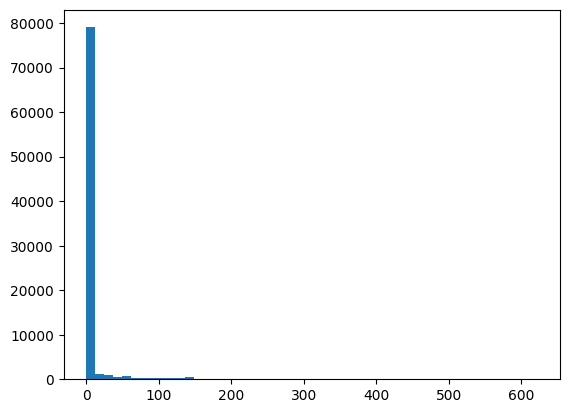

In [197]:
plt.hist(df["Resolution_Days"], bins=50)

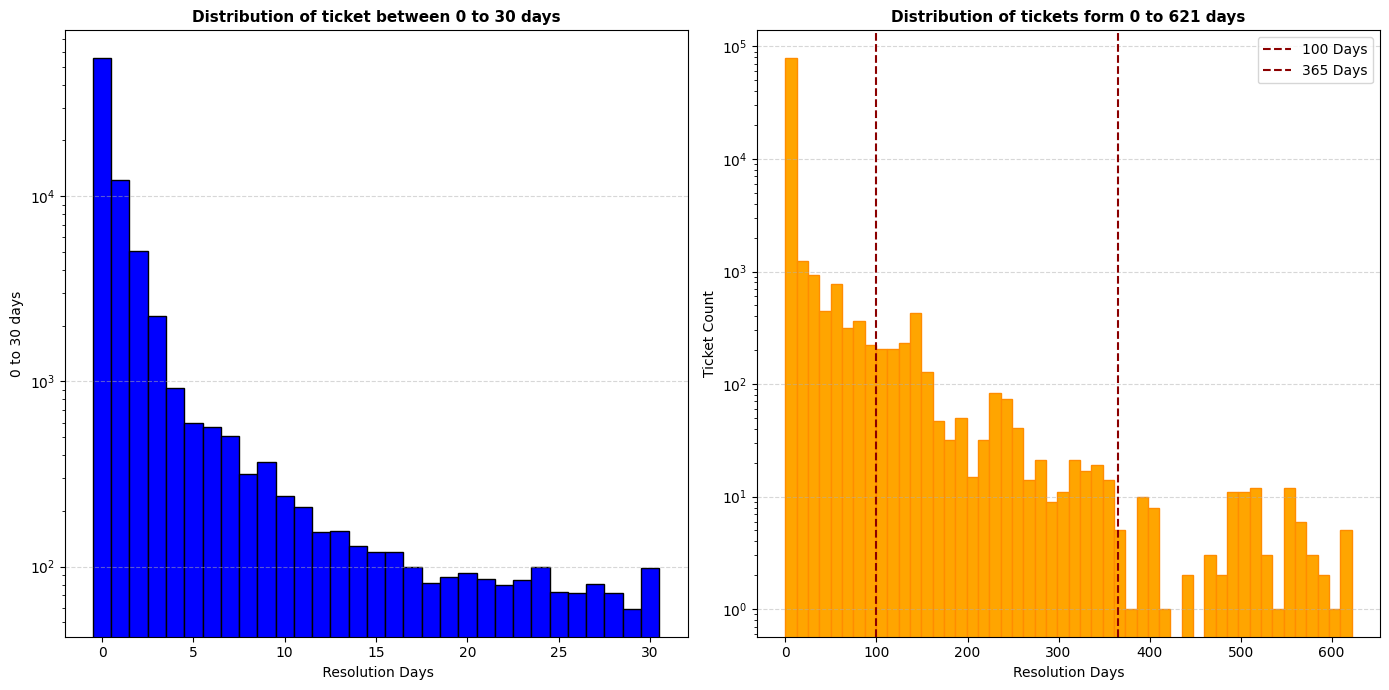

In [198]:
fig, axes = plt.subplots(1,2, figsize=(14,7))

# Plot 1
zoomed_data = df[df["Resolution_Days"] <= 30]["Resolution_Days"]

axes[0].hist(
    zoomed_data,
    color ="blue",
    edgecolor= "black",
    bins = range(0,32),
    align = "left",
    log = True
)

axes[0].set_title(
    "Distribution of ticket between 0 to 30 days",
    fontweight = "bold",
    fontsize = 11
)
axes[0].set_xlabel(" Resolution Days")
axes[0].set_ylabel("0 to 30 days")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

# Plot 2

axes[1].hist(
    df["Resolution_Days"],
    bins=50,
    color="orange",
    edgecolor = "darkorange",
    log=True
)

axes[1].set_title(
    "Distribution of tickets form 0 to 621 days",
    fontweight = "bold",
    fontsize=11
    )

axes[1].axvline(
    100, color="darkred", 
    linestyle ="--", 
    linewidth="1.5",
    label = "100 Days"
)

axes[1].axvline(
    365, color="darkred", 
    linestyle ="--", 
    linewidth="1.5",
    label = "365 Days"
)

axes[1].set_xlabel("Resolution Days")
axes[1].set_ylabel("Ticket Count")
axes[1].grid(axis='y', linestyle="--", alpha=0.5)
axes[1].legend()
plt.tight_layout()
plt.show()

### Quantitative Characterization of Extreme Outliers (>100 Days and >365 Days)

Quantify the volume, statistical spread, and proportion of severe delays across the citywide dataset:

* **Moderate-to-Severe Outliers ($>100$ Days):**
  * **Volume & Share:** Comprises **1,783 tickets**, representing just **2.09%** of all 85,122 citywide records.
  * **Turnaround Metrics:** Within this subset, the **Median is 138.0 days**, the **Mean is 181.67 days**, and the longest case reached **622 days** (~1.7 years).
* **Severe Multi-Year Outliers ($>365$ Days):**
  * **Volume & Share:** Drops sharply to **98 tickets**, accounting for merely **0.12%** of the entire dataset (~1 out of every 870 tickets).
  * **Turnaround Metrics:** Cases exceeding a full calendar year carry a **Median of 507.0 days** (~1.4 years) and an arithmetic **Mean of 496.73 days**, terminating at **622 days**.
* **Takeaway:** Severe resolution delays do not represent systemic, citywide operational inertia. Rather, they are confined to a tiny fraction of total caseload ($2.09\%$ over 100 days; $0.12\%$ over 1 year), mathematically confirming that the long tail is driven by specialized casework rather than routine municipal services.

In [199]:
total_tickets = len(df)

over_100_days = df[df["Resolution_Days"] > 100]
over_365_days = df[df["Resolution_Days"] > 365]

extreme_summery = pd.DataFrame(
    {
        "Threshold": ["> 100 Days", "> 365 Days"],
        "Ticket_Counts": [len(over_100_days), len(over_365_days)],
        "Pct_of_total": [
            f"{(len(over_100_days) / total_tickets) * 100:.2f}%",
            f"{(len(over_365_days) / total_tickets ) * 100:.2f}%" 
        ],

        "Min_Days": [
            over_100_days["Resolution_Days"].min(),
            over_365_days["Resolution_Days"].min(),
        ],
        "Median_Days": [
            over_100_days["Resolution_Days"].median(),
            over_365_days["Resolution_Days"].median()
        ],
        "Mean_Days": [
            over_100_days["Resolution_Days"].mean().round(2),
            over_365_days["Resolution_Days"].mean().round(2)
        ],
        "Max_Days": [
            over_100_days["Resolution_Days"].max(),
            over_365_days["Resolution_Days"].max()
        ]
    }
)

In [200]:
extreme_summery

,Threshold,Ticket_Counts,Pct_of_total,Min_Days,Median_Days,Mean_Days,Max_Days
0,> 100 Days,1783,2.09%,101,138.0,181.67,622
1,> 365 Days,98,0.12%,366,507.0,496.73,622


### Agency Concentration of Moderate-to-Severe Delays (>100 Days)

Inspect the agency distribution across the 1,783 tickets that exceeded 100 days to resolve:

* **Heavy Concentration in Top 3 Departments (80.59% Share):**
  * `HPD`: **668 tickets** (**37.46%** of all 100+ day delays). While heating calls resolve rapidly, HPD's immense intake and persistent non-heating backlog (e.g., unsanitary conditions, structural maintenance) make it the largest absolute contributor to extreme delays.
  * `EDC`: **452 tickets** (**25.35%** of all 100+ day delays). Despite low overall ticket intake, virtually its entire helicopter noise portfolio exceeds 100 days due to federal FAA/aviation review timelines.
  * `DOB`: **317 tickets** (**17.78%** of all 100+ day delays). Driven by extensive inspection backlogs, engineering reviews, and stop-work order audits.
* **Secondary Infrastructure & Regulatory Contributors:**
  * `DPR` (**106 tickets**, 5.95%) and `DOT` (**95 tickets**, 5.33%): Driven by physical field operations such as tree removals/stump grinding and street light fixture replacements.
  * `TLC` (**76 tickets**, 4.26%): Driven by tribunal scheduling (OATH) and administrative summons hearings for driver/vehicle violations.
  * `DHS` (**42 tickets**, 2.36%): Driven exclusively by complex encampment cleanups and multi-agency outreach.
* **Analytical Takeaway:** Three agencies (`HPD`, `EDC`, `DOB`) account for over 8 out of every 10 tickets in the city that take more than 100 days. The extreme tail is divided between HPD's raw volume of maintenance casework and the specialized regulatory/inspection tasks of EDC and DOB.

In [201]:
agency_over_100 = (
    over_100_days["Agency"]
    .value_counts()
    .reset_index(name="Tickets_Over_100")
    .rename(columns={"index": "Agency"})
)
agency_over_100["Pct_Share"] = (
    (agency_over_100["Tickets_Over_100"] / len(over_100_days) * 100).round(2)
)

print("\n--- Top Agencies Responsible for Cases > 100 Days ---")
display(agency_over_100.head(7))


--- Top Agencies Responsible for Cases > 100 Days ---


,Agency,Tickets_Over_100,Pct_Share
0,HPD,668,37.46
1,EDC,452,25.35
2,DOB,317,17.78
3,DPR,106,5.95
4,DOT,95,5.33
5,TLC,76,4.26
6,DHS,42,2.36


In [204]:
top_complaints_100 = (
    over_100_days["Complaint_Type"]
    .value_counts()
    .rename_axis("Complaint_Type")
    .reset_index(name="Tickets_Over_100")
)

top_complaints_100["Pct_share_of_100_pool"] = (
    (top_complaints_100["Tickets_Over_100"] / len(over_100_days)) * 100
).round(2)

top_complaints_365 = (
    over_365_days["Complaint_Type"]
    .value_counts()
    .rename_axis("Complaint_Type")
    .reset_index(name="Tickets_Over_365")
)

top_complaints_365["Pct_share_of_365_Pool"] = (
    (top_complaints_365["Tickets_Over_365"] / len(over_365_days)) * 100
).round(2)


print("--- Top Complaint Types Driving Cases > 100 Days ---")
display(top_complaints_100.head(10))

print("\n--- Top Complaint Types Driving Cases > 365 Days ---")
display(top_complaints_365.head(10))

--- Top Complaint Types Driving Cases > 100 Days ---


,Complaint_Type,Tickets_Over_100,Pct_share_of_100_pool
0,Noise - Helicopter,452,25.35
1,Unsanitary Condition,163,9.14
2,Building/Use,105,5.89
3,Elevator,98,5.50
4,General,91,5.10
5,Plumbing,89,4.99
6,Door/Window,88,4.94
7,General Construction/Plumbing,70,3.93
8,Water Leak,55,3.08
9,Paint/Plaster,48,2.69



--- Top Complaint Types Driving Cases > 365 Days ---


,Complaint_Type,Tickets_Over_365,Pct_share_of_365_Pool
0,Special Projects Inspection Team (Spit),27,27.55
1,General Construction/Plumbing,10,10.20
2,School Maintenance,9,9.18
3,Maintenance Or Facility,8,8.16
4,Water System,8,8.16
5,Street Light Condition,8,8.16
6,Dead/Dying Tree,7,7.14
7,Building/Use,6,6.12
8,Sidewalk Condition,4,4.08
9,Damaged Tree,2,2.04
